# Wine Quality Prediction – EDA & Classification

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This project analyses physicochemical properties of red and white wine to predict quality ratings. It explores how alcohol, acidity, sulphates, and other compounds affect perceived quality. The insights help winemakers focus on key attributes. The notebook includes 10 visualisations and a random forest classifier to distinguish good vs poor quality wine.

## Dataset
- **Source:** UCI Wine Quality Dataset
- **Rows:** 6,497 samples (red + white)
- **Features:** 11 chemical properties + quality score (0-10)

## Key Steps
1. Load and combine red and white wine datasets
2. Exploratory analysis with visualisations
3. Convert quality score into binary classes (good = quality ≥ 7)
4. Train random forest classifier
5. Evaluate feature importance and model performance

## Requirements
- pandas, matplotlib, seaborn, scikit-learn

---

**© 2026 Ibrahim – Wine quality analytics.**

### Install & Imports

In [2]:
!pip install -q pandas matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Load Dataset (Red and White Wine)

In [3]:
# URLs for red and white wine datasets
url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

# Load with semicolon separator
df_red = pd.read_csv(url_red, sep=';')
df_white = pd.read_csv(url_white, sep=';')

# Add wine type column
df_red['wine_type'] = 'red'
df_white['wine_type'] = 'white'

# Combine
df = pd.concat([df_red, df_white], ignore_index=True)

print(f"Red wine samples: {len(df_red)}")
print(f"White wine samples: {len(df_white)}")
print(f"Total samples: {len(df)}")
df.head(2)

Red wine samples: 1599
White wine samples: 4898
Total samples: 6497


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red


### Data Overview & Quality Distribution

In [4]:
print("Quality score distribution:")
print(df['quality'].value_counts().sort_index())

# Create binary target: good quality (quality >= 7)
df['quality_binary'] = (df['quality'] >= 7).astype(int)
print(f"\nGood quality (≥7) proportion: {df['quality_binary'].mean()*100:.2f}%")

Quality score distribution:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

Good quality (≥7) proportion: 19.66%


### Quality Score Distribution

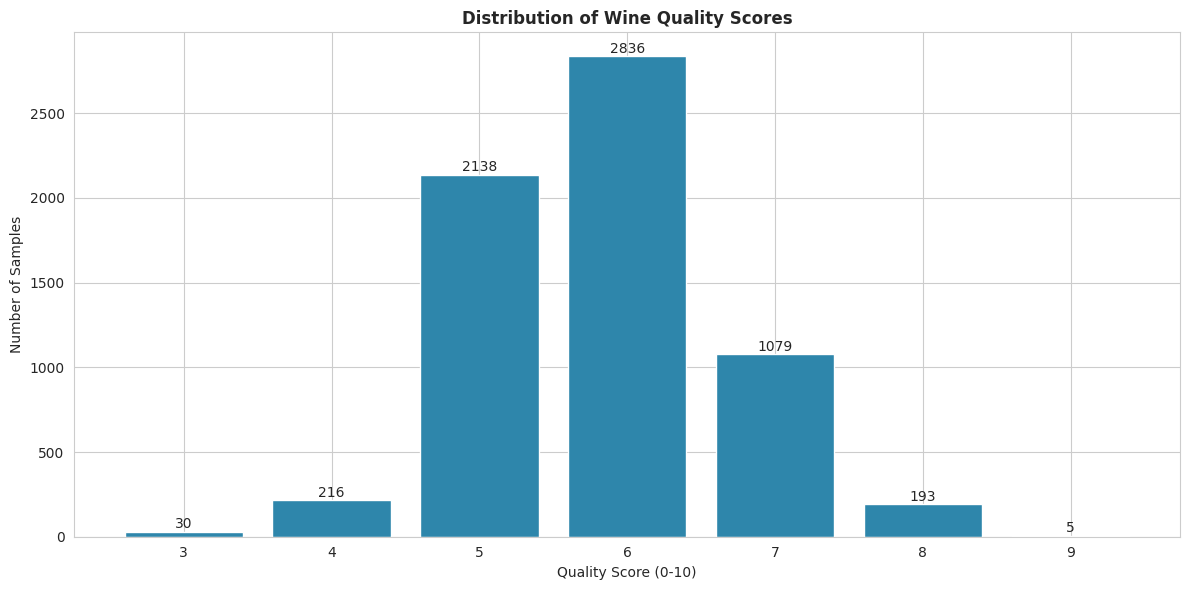

In [5]:
quality_counts = df['quality'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
bars = plt.bar(quality_counts.index, quality_counts.values, color='#2E86AB')
plt.xlabel('Quality Score (0-10)')
plt.ylabel('Number of Samples')
plt.title('Distribution of Wine Quality Scores', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 20, f'{int(height)}', ha='center')
plt.tight_layout()
plt.show()

### Quality by Wine Type (Violin Plot)

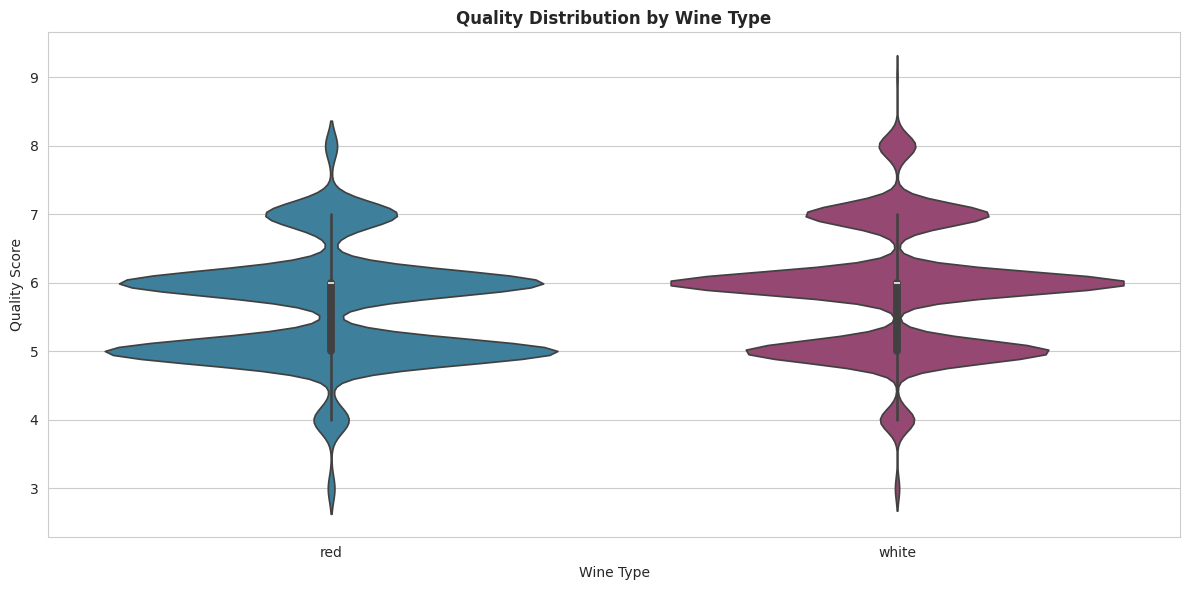

In [6]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='wine_type', y='quality', palette=['#2E86AB', '#A23B72'])
plt.xlabel('Wine Type')
plt.ylabel('Quality Score')
plt.title('Quality Distribution by Wine Type', fontweight='bold')
plt.tight_layout()
plt.show()

### Alcohol vs Quality (Scatter with Trend)

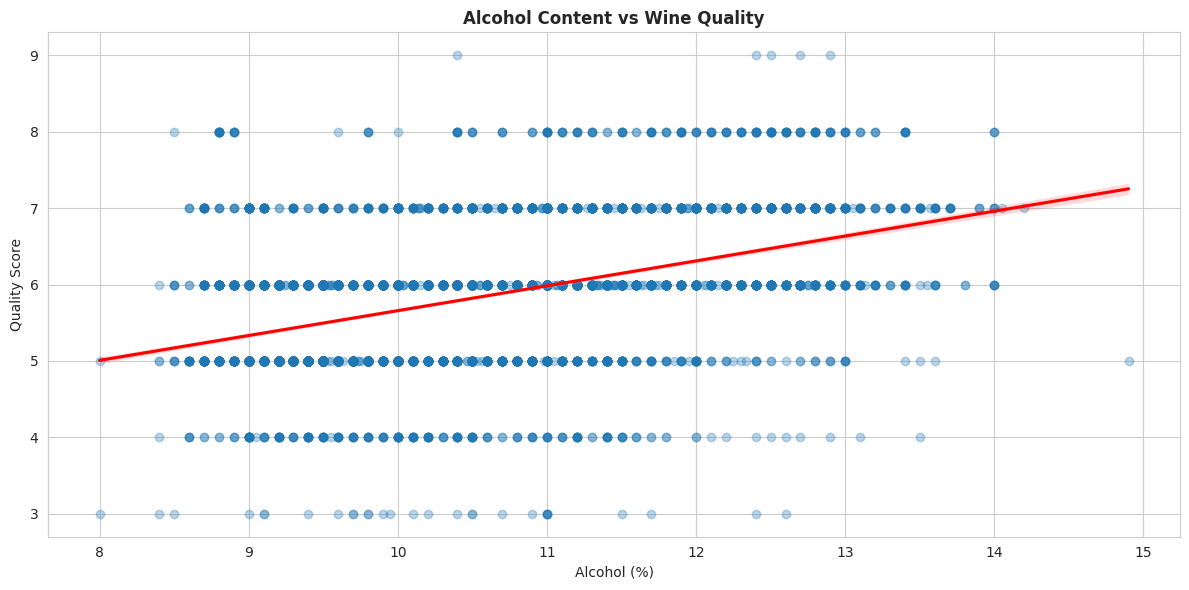

In [7]:
plt.figure(figsize=(12, 6))
sns.regplot(data=df, x='alcohol', y='quality', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Alcohol (%)')
plt.ylabel('Quality Score')
plt.title('Alcohol Content vs Wine Quality', fontweight='bold')
plt.tight_layout()
plt.show()

### Volatile Acidity vs Quality (Box Plot)

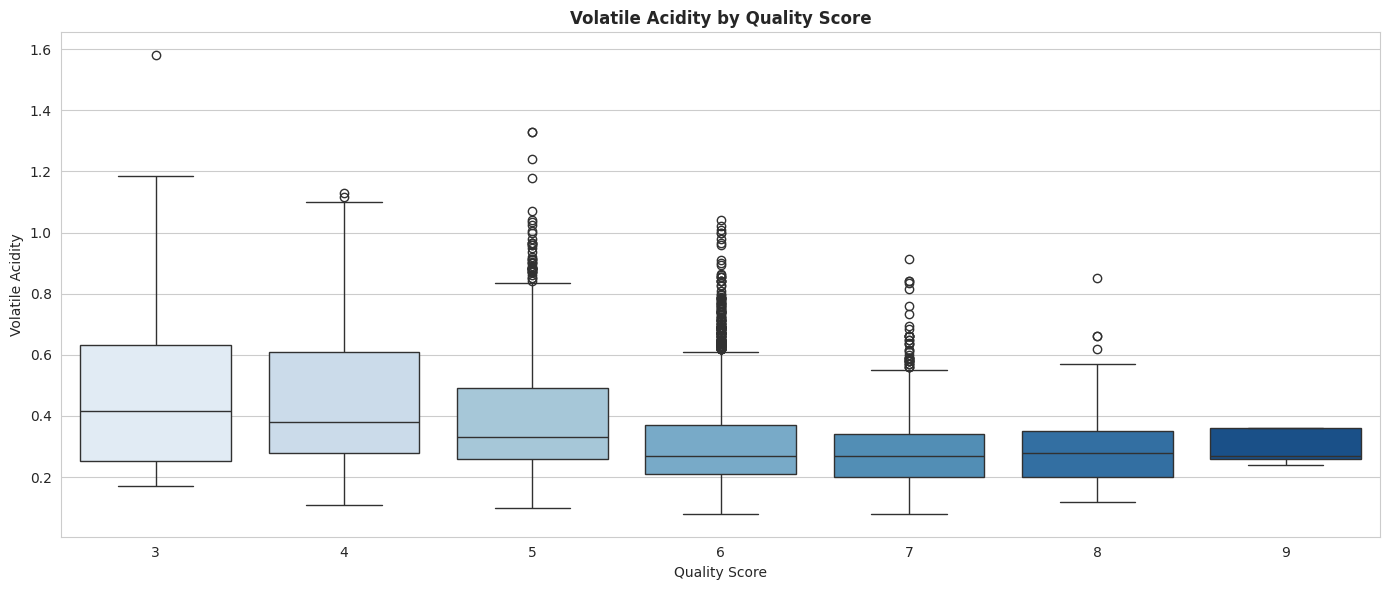

In [8]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='quality', y='volatile acidity', palette='Blues')
plt.xlabel('Quality Score')
plt.ylabel('Volatile Acidity')
plt.title('Volatile Acidity by Quality Score', fontweight='bold')
plt.tight_layout()
plt.show()

### Citric Acid Distribution by Quality (Histogram)

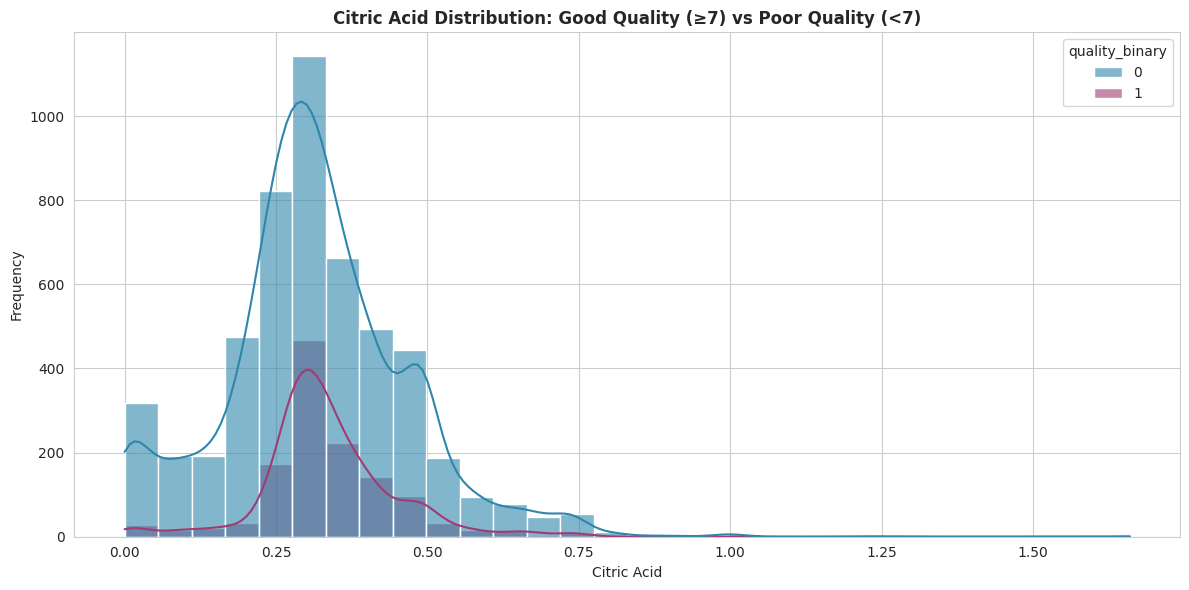

In [9]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='citric acid', hue='quality_binary', bins=30, kde=True, palette=['#2E86AB', '#A23B72'], alpha=0.6)
plt.xlabel('Citric Acid')
plt.ylabel('Frequency')
plt.title('Citric Acid Distribution: Good Quality (≥7) vs Poor Quality (<7)', fontweight='bold')
plt.tight_layout()
plt.show()

### pH vs Quality (Box Plot)

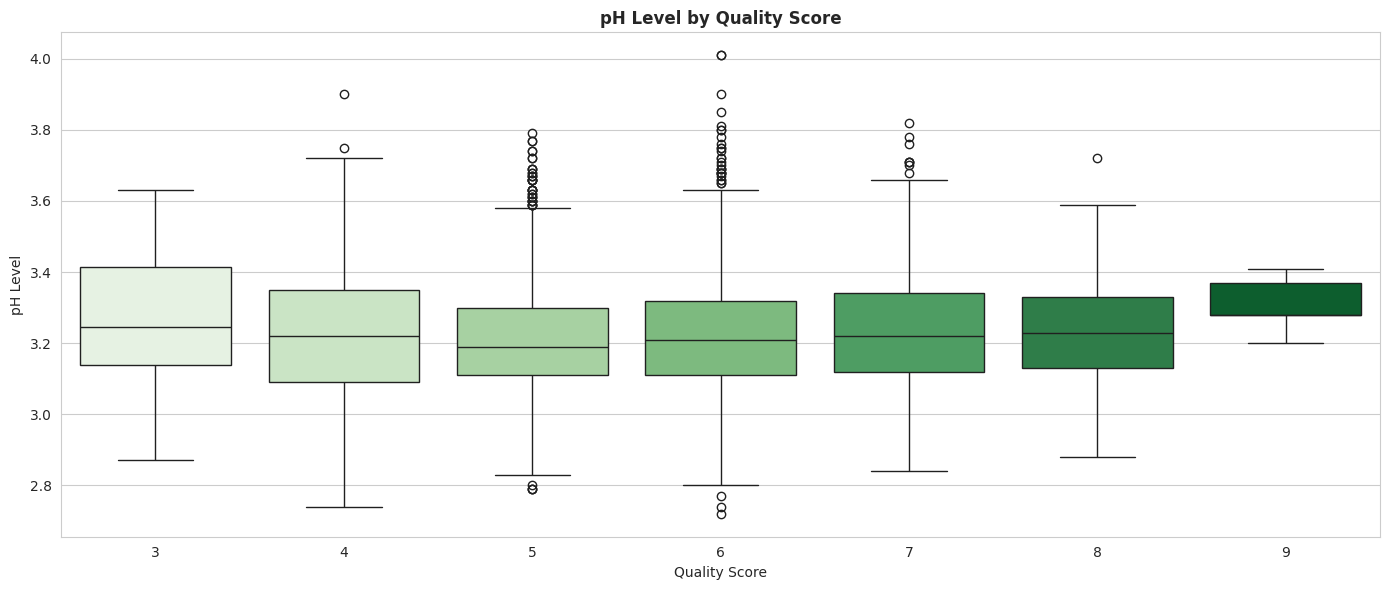

In [10]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='quality', y='pH', palette='Greens')
plt.xlabel('Quality Score')
plt.ylabel('pH Level')
plt.title('pH Level by Quality Score', fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation Heatmap

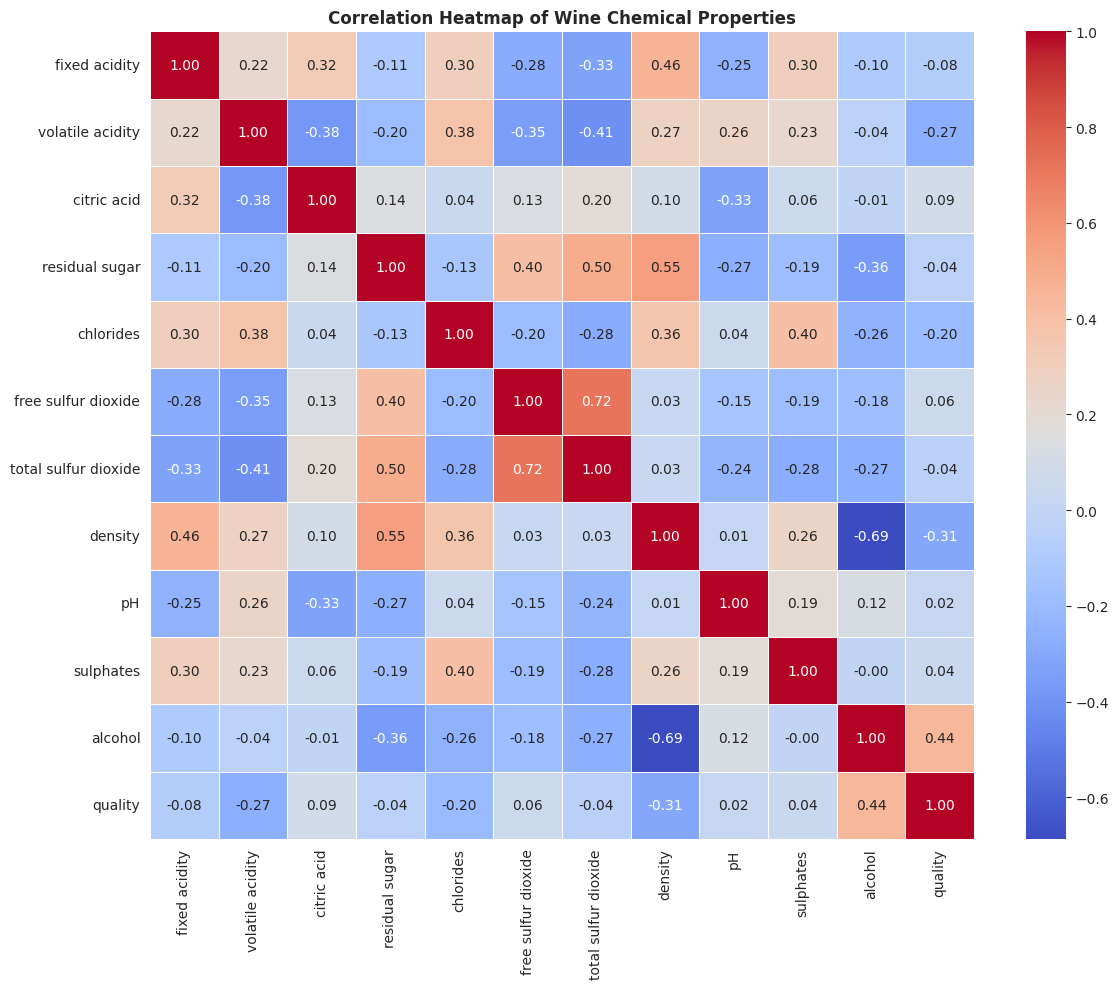

In [11]:
# Select numeric columns (exclude quality_binary and wine_type for correlation)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['quality_binary']]
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Wine Chemical Properties', fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Importance from Random Forest

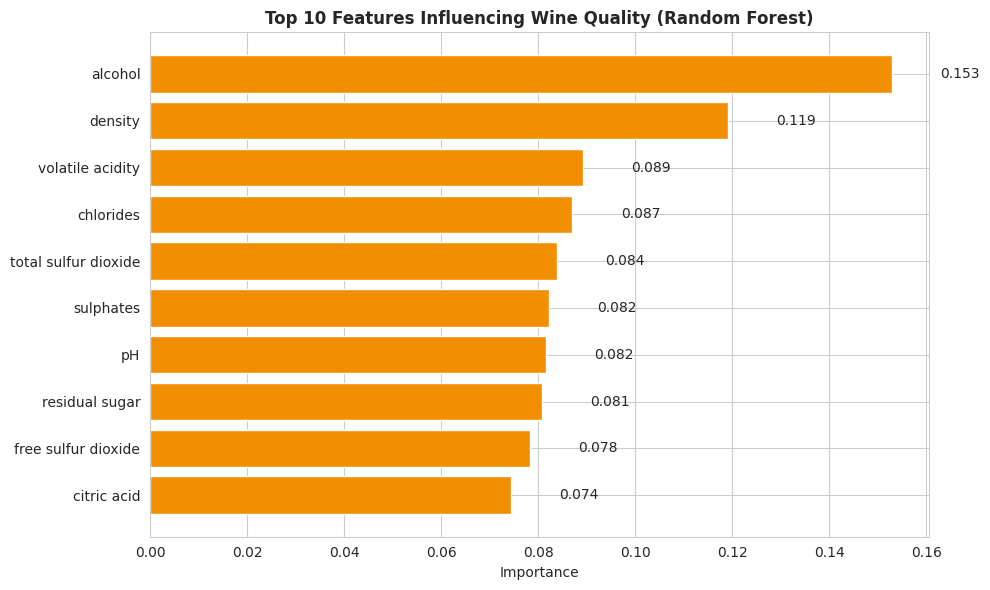

In [12]:
# Prepare features (drop quality and quality_binary, but keep wine_type as numeric)
df_model = df.copy()
# Encode wine_type as numeric
df_model['wine_type'] = df_model['wine_type'].map({'red': 0, 'white': 1})

feature_cols = [c for c in df_model.columns if c not in ['quality', 'quality_binary']]
X = df_model[feature_cols]
y = df_model['quality_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance['feature'][::-1], feature_importance['importance'][::-1], color='#F18F01')
plt.xlabel('Importance')
plt.title('Top 10 Features Influencing Wine Quality (Random Forest)', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center')
plt.tight_layout()
plt.show()

### Confusion Matrix

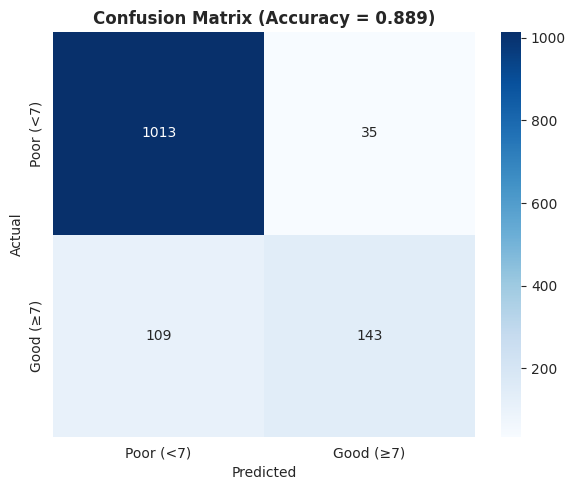

              precision    recall  f1-score   support

   Poor (<7)       0.90      0.97      0.93      1048
   Good (≥7)       0.80      0.57      0.67       252

    accuracy                           0.89      1300
   macro avg       0.85      0.77      0.80      1300
weighted avg       0.88      0.89      0.88      1300



In [13]:
y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Poor (<7)', 'Good (≥7)'], yticklabels=['Poor (<7)', 'Good (≥7)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Accuracy = {accuracy:.3f})', fontweight='bold')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Poor (<7)', 'Good (≥7)']))

### Pairplot of Top 4 Features

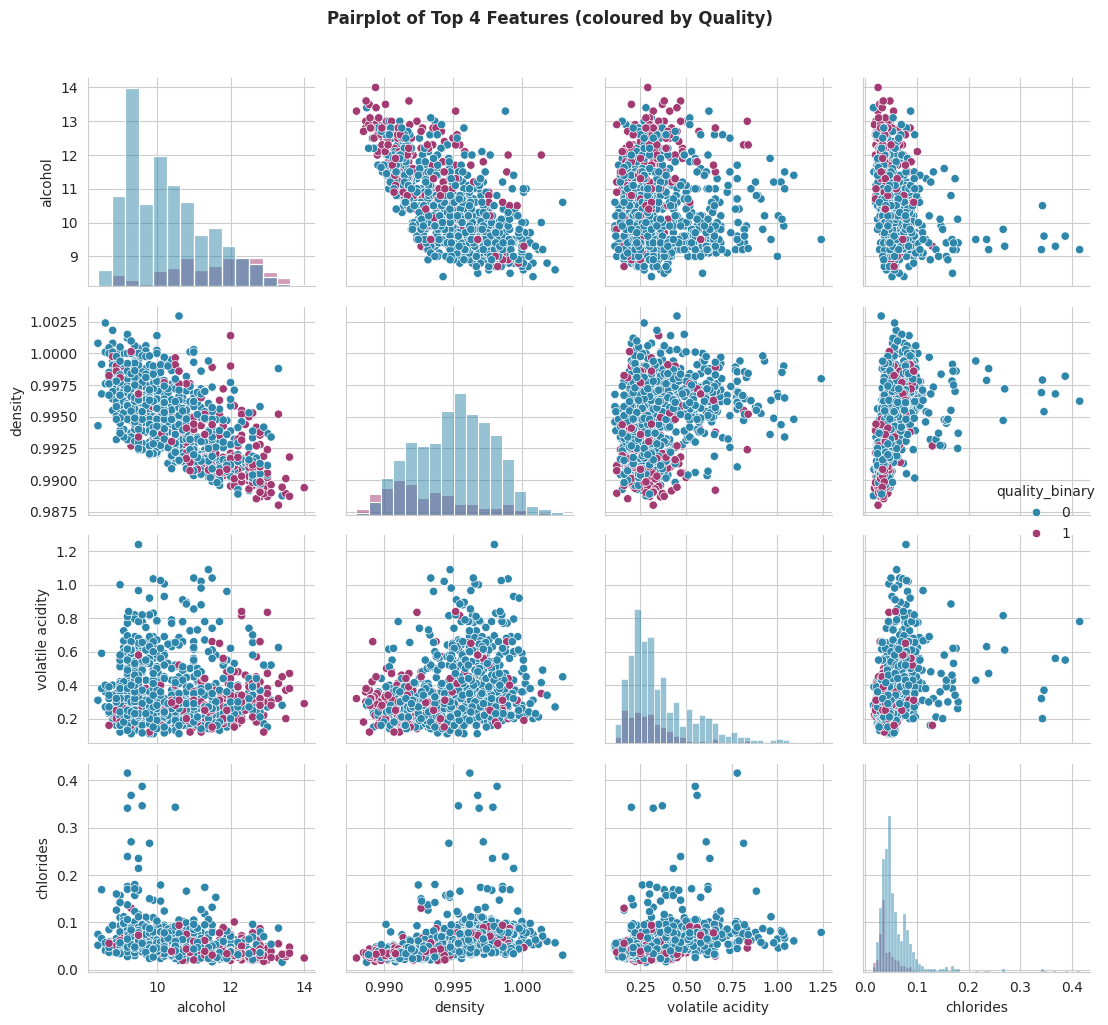

In [14]:
# Select top 4 features based on importance
top_features = feature_importance['feature'].head(4).tolist()
top_features.append('quality_binary')

# Sample 1000 points for readability
sample_df = df[top_features].sample(n=1000, random_state=42)

sns.pairplot(sample_df, hue='quality_binary', palette=['#2E86AB', '#A23B72'], diag_kind='hist')
plt.suptitle('Pairplot of Top 4 Features (coloured by Quality)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Insights Summary

In [15]:
print(" Key Insights from Wine Quality Analysis")
print(f" Total samples: {len(df)} (Red: {len(df_red)}, White: {len(df_white)})")
print(f" Good quality wine (≥7) proportion: {df['quality_binary'].mean()*100:.2f}%")
print(f" Alcohol has highest correlation with quality: {df['alcohol'].corr(df['quality']):.2f}")
print(f" Top 3 features: {feature_importance['feature'].iloc[0]}, {feature_importance['feature'].iloc[1]}, {feature_importance['feature'].iloc[2]}")
print(f" Random forest accuracy: {accuracy:.3f}")
print(" Classification model built and evaluated.")

 Key Insights from Wine Quality Analysis
 Total samples: 6497 (Red: 1599, White: 4898)
 Good quality wine (≥7) proportion: 19.66%
 Alcohol has highest correlation with quality: 0.44
 Top 3 features: alcohol, density, volatile acidity
 Random forest accuracy: 0.889
 Classification model built and evaluated.


### Final Summary

In [16]:
print("Wine Quality Prediction - COMPLETED")
print("Author: Ibrahim")
print("Dataset loaded and combined.")
print("Key chemical drivers of quality identified.")
print("Model ready for winemaking recommendations.")

Wine Quality Prediction - COMPLETED
Author: Ibrahim
Dataset loaded and combined.
Key chemical drivers of quality identified.
Model ready for winemaking recommendations.
